# Reading science and temperature data
- Reads in temperature packet data
- Reads in a single science data file
- Plots them both
- Fits the FWHM for a single channel

Data files available on [IMPISH Google Drive](https://drive.google.com/drive/folders/1cImwB9ipLQIxjj8sYXwNGbia3ZMFlKsY)

In [1]:
from impisc.daqbox import daqbox_api as dba
from impisc.packets import TemperaturePacket
import pathlib
import ctypes
from matplotlib import pyplot as plt
from astropy import units as u
import astropy.time as atime
import numpy as np
import pathlib

import scipy.optimize as sco

import science_support

%matplotlib inline
%config InlineBackend.figure_format = "retina"
plt.style.use("nice.mplstyle")

## Read & plot the temperature data

In [2]:
import lzma
direc = pathlib.Path("long-duration-am241-assembled/temps/")
sipm_temps = list()
times = list()

for filename in direc.iterdir():
    with lzma.open(filename, "rb") as file:
        while True:
            data = file.read(ctypes.sizeof(TemperaturePacket))
            if len(data) == 0:
                break
            packet = TemperaturePacket.from_buffer_copy(data)
            sipm_temps.append(packet.daqbox_ch2)
            times.append(packet.timestamp)


sipm_temps = sipm_temps << (0.1 * u.deg_C)
times = atime.Time(times, format="unix")

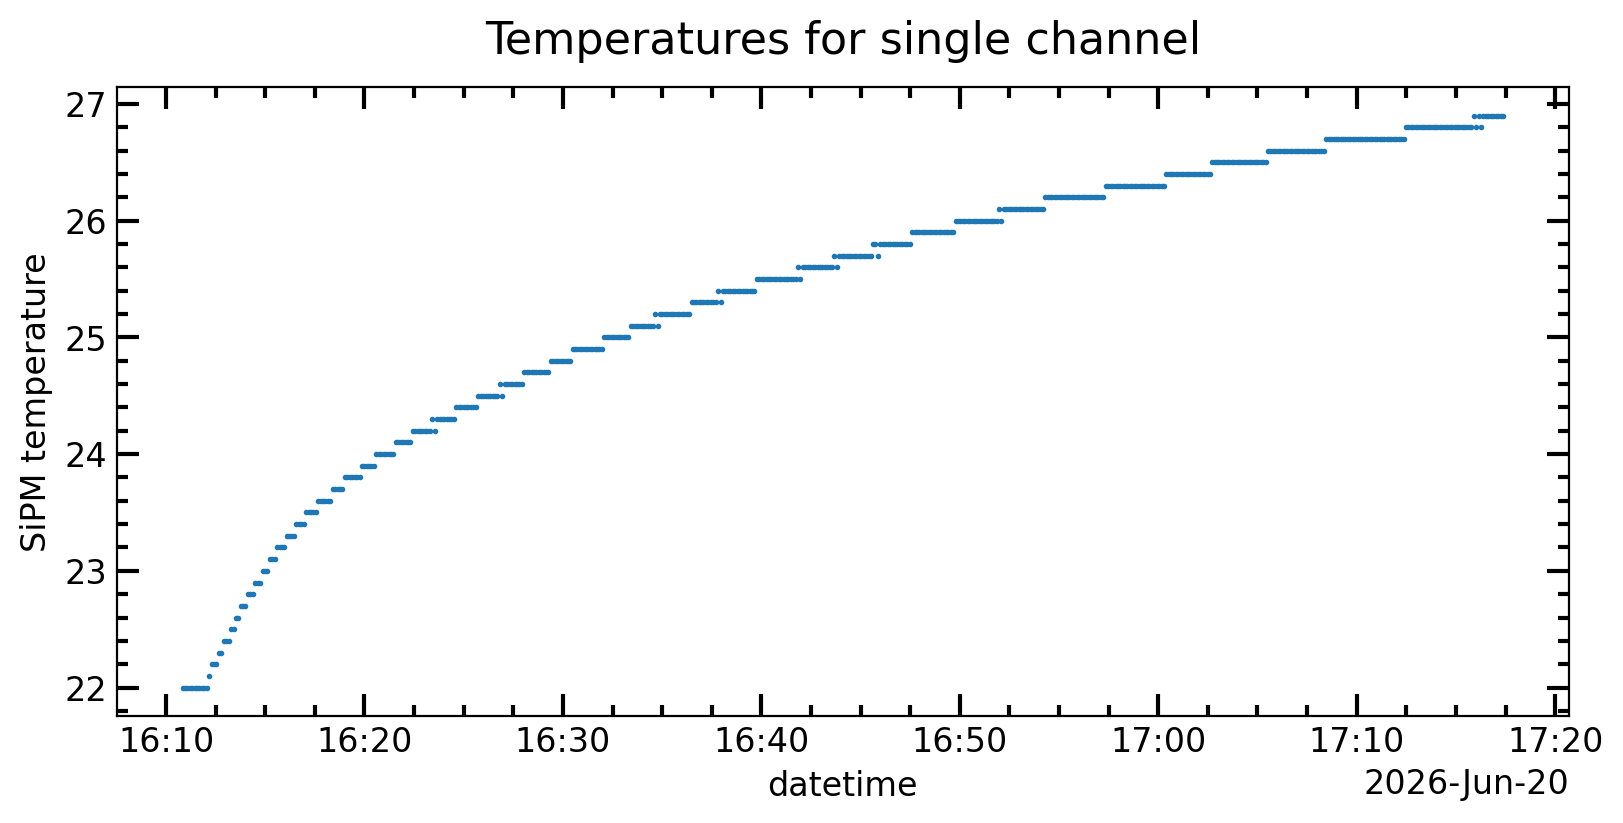

In [3]:
fig, ax = plt.subplots()
ax.scatter(times.datetime, sipm_temps.to_value(u.deg_C), s=1)
ax.set(xlabel='datetime', ylabel='SiPM temperature', title="Temperatures for single channel")
plt.show()

## Load, rebin, and plot science data

In [4]:
# Download from Google Drive
example = 'long-duration-am241-assembled/science_2026-171-17-05-30_0.bin.bz2'
data = science_support.load_science_file(example)

### Plot spectra summed across the science file

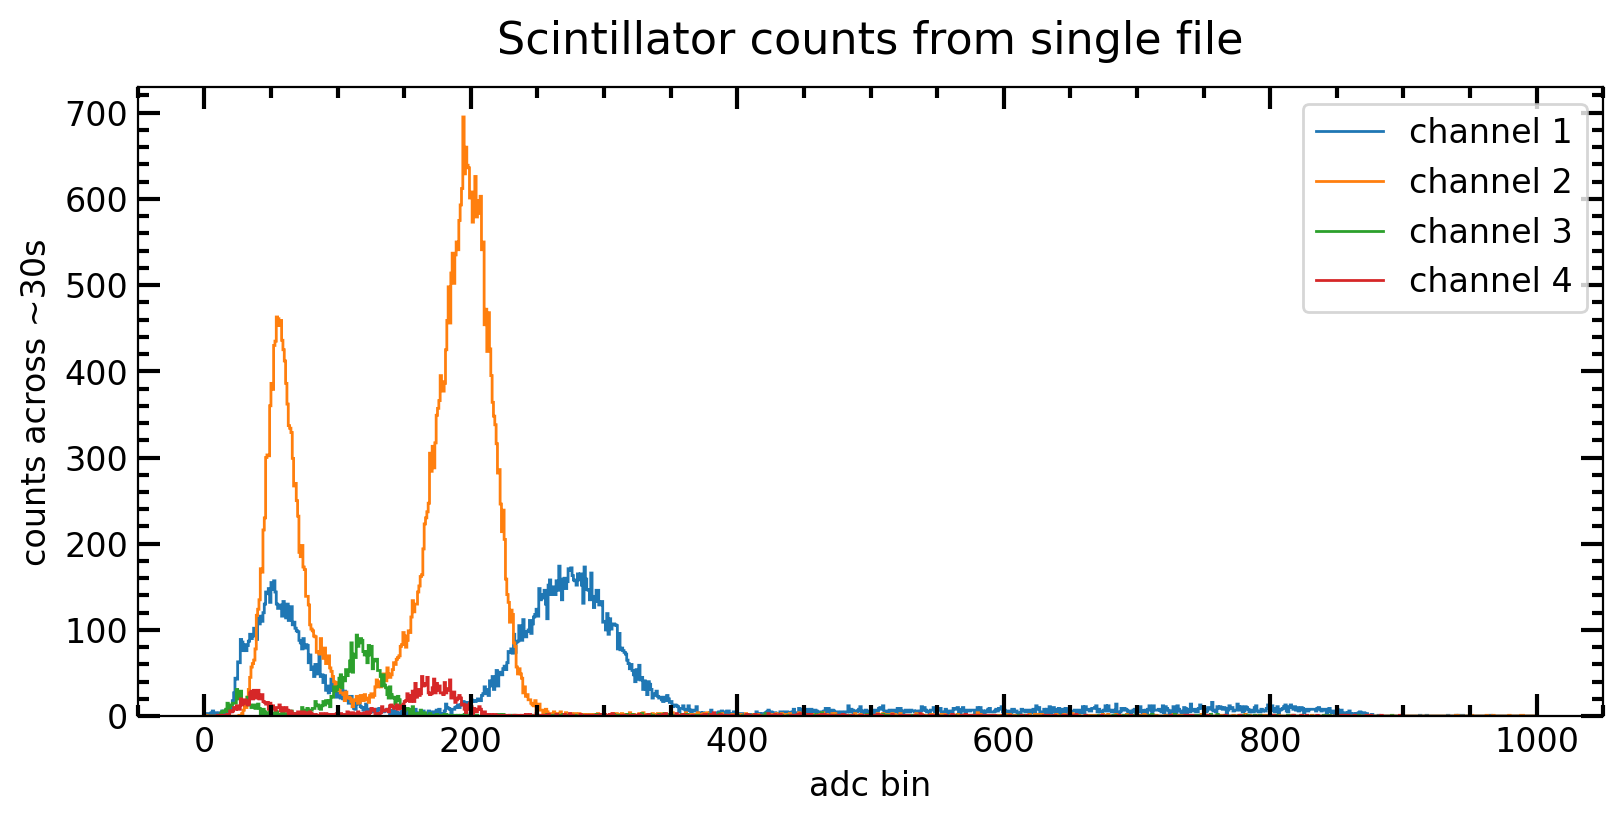

In [5]:
summed_spectra = data["spectra"].sum(axis=0)

fig, ax = plt.subplots()
adc_bins = np.arange(1001)
for i in range(summed_spectra.shape[0]):
    s = summed_spectra[i]
    ax.stairs(s, adc_bins, label=f"channel {i+1}")
ax.legend()
ax.set(xlabel='adc bin', ylabel=f'counts across ~30s', title="Scintillator counts from single file")
plt.show()

### Rebin the spectrogram across energy and time

In [6]:
import importlib
importlib.reload(science_support)

rebinned = science_support.rebin_time_energy(
    science_records=data,
    resulting_adc_bins=(resulting_adc_bins := 250),
    # Sum across 0.25s of data per time bin
    time_combine_factor=8
)

Text(0.5, 0.98, 'Spectrogram from a single file, binned down, log-colored')

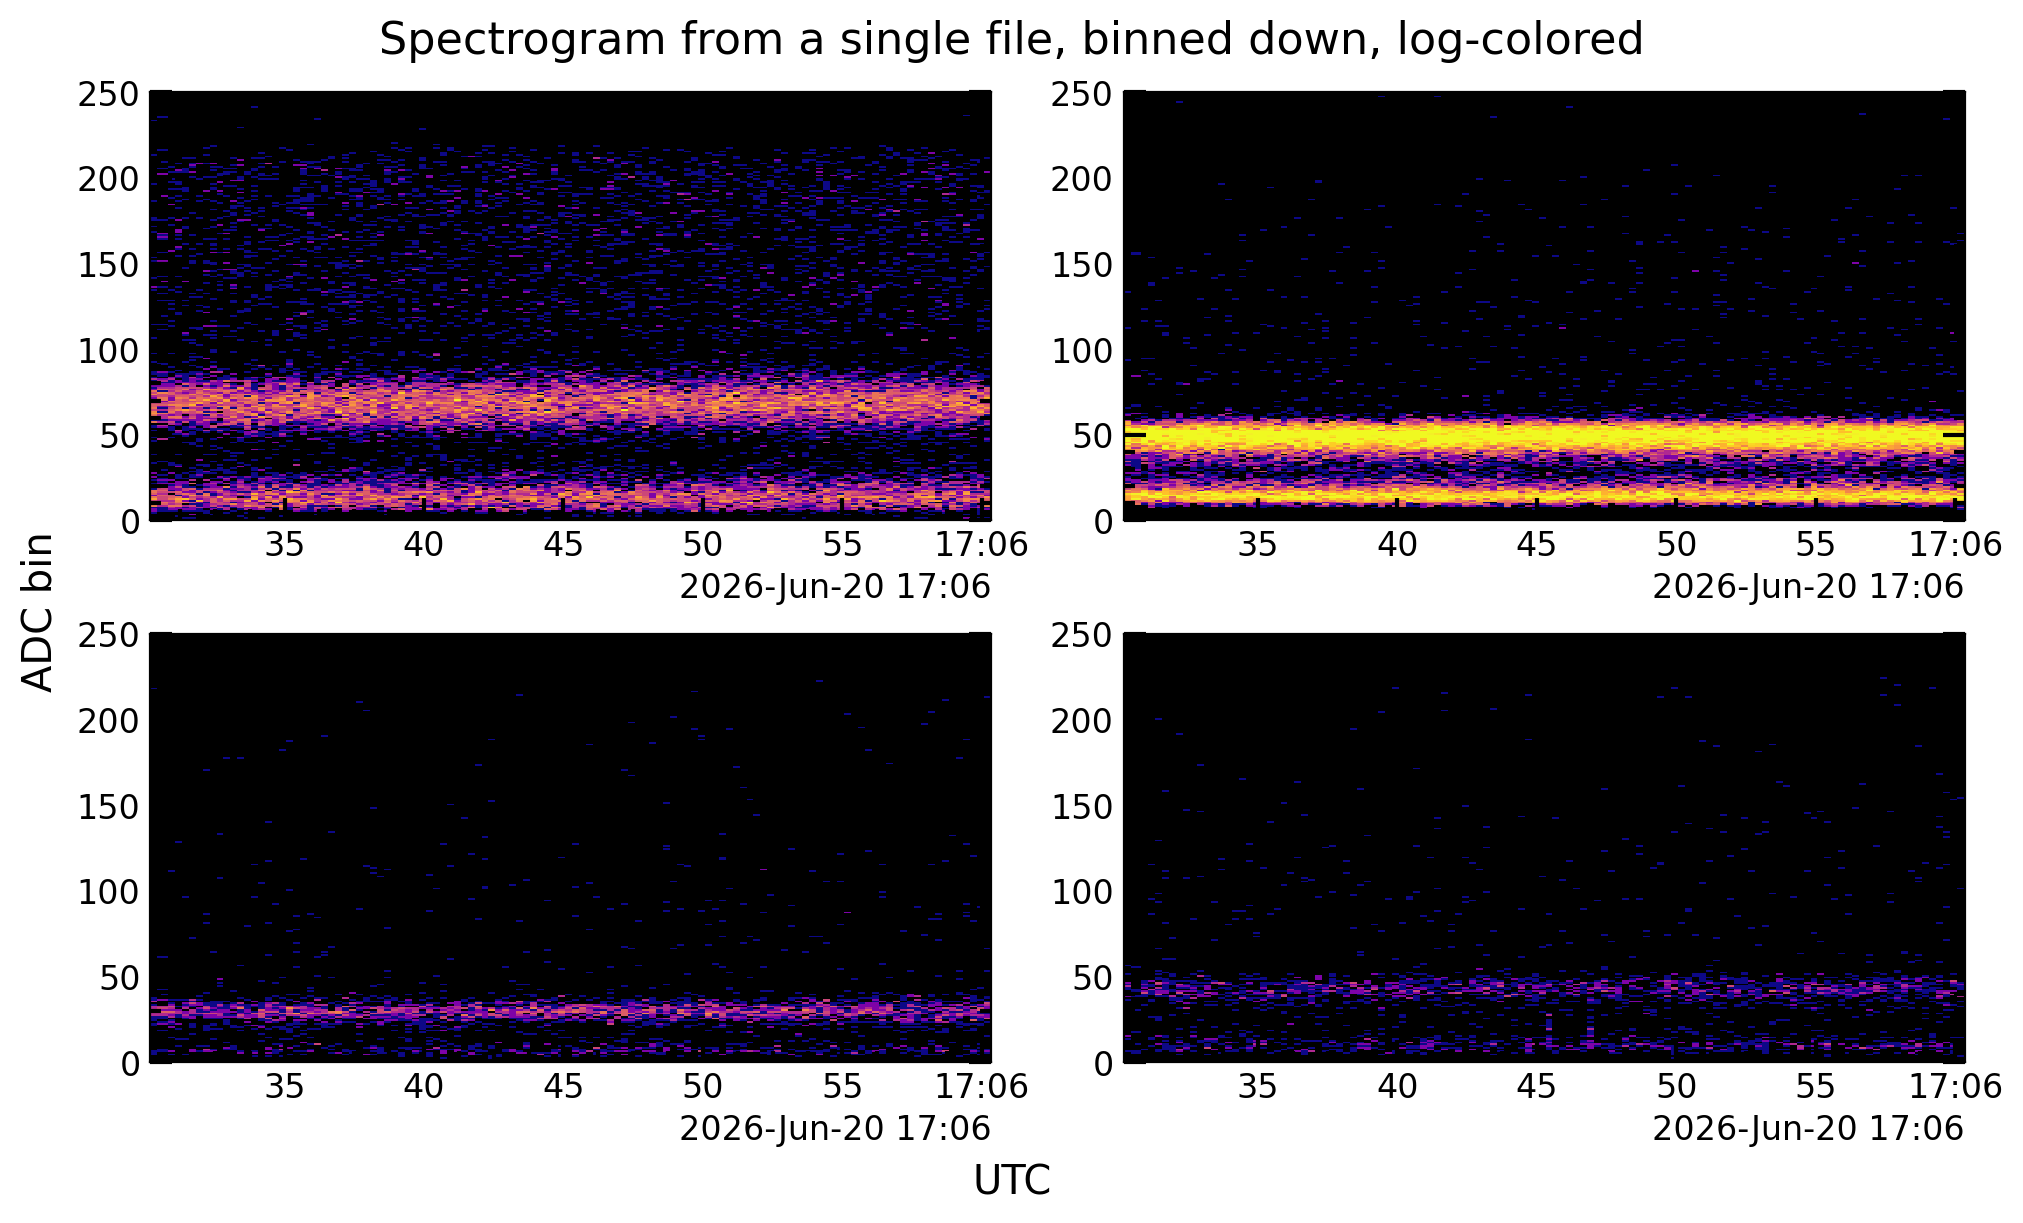

In [7]:
import matplotlib.colors as mcol

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(10, 6))
axs = axs.flatten()

ebins = np.arange(resulting_adc_bins + 1)
norm = mcol.LogNorm()
cm = plt.get_cmap("plasma").copy()
cm.set_bad("black")

for chi in range(4):
    spectrogram = rebinned["spectra"][chi]
    axs[chi].pcolormesh(
        rebinned["time_bins"].datetime,
        ebins,
        spectrogram.T,
        norm=norm,
        cmap=cm,
    )

fig.supxlabel("UTC")
fig.supylabel("ADC bin")
fig.suptitle("Spectrogram from a single file, binned down, log-colored")

## Fit the rebinned spectra

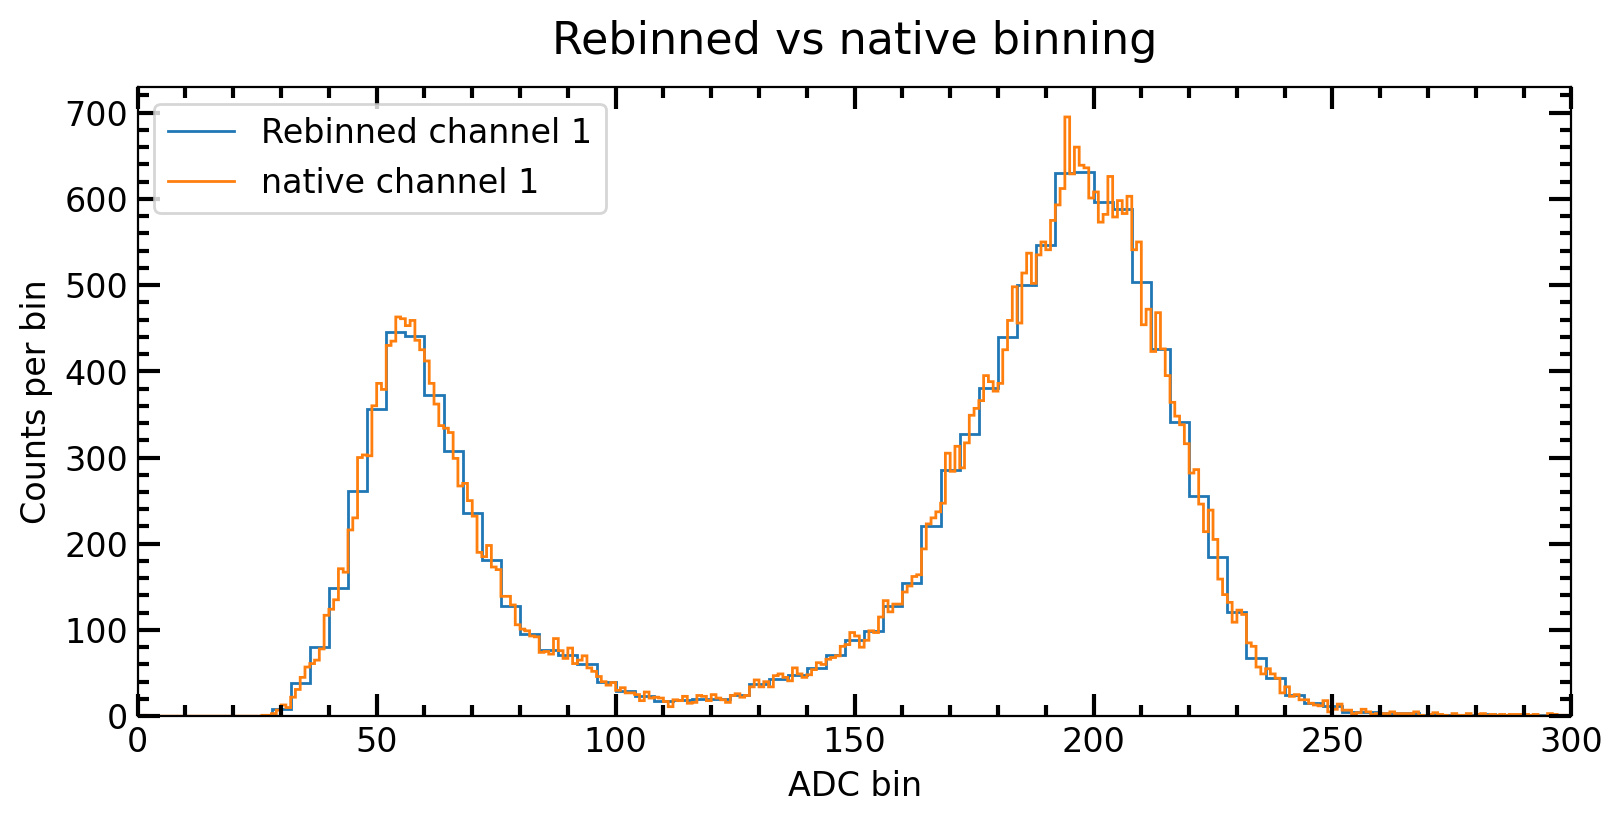

In [8]:
rebinned_spectra = rebinned["spectra"].sum(axis=1)

# Channel 1 is the uncollimated YAP, and the quietest.
ch = 1

fig, ax = plt.subplots()

native_bins = np.arange(1001)
bin_scale_factor = int(1000 / rebinned_spectra.shape[1])
rebinned_bins = native_bins[::bin_scale_factor]
ax.stairs(rebinned_spectra[ch] / bin_scale_factor, rebinned_bins, label=f'Rebinned channel {ch}')
ax.stairs(summed_spectra[ch], native_bins, label=f"native channel {ch}")
ax.legend()

ax.set(ylabel='Counts per bin', xlabel='ADC bin', xlim=(0, 300), title='Rebinned vs native binning')
plt.show()

In [9]:
def gauss(x, amp, mu, wid):
    return amp * np.exp(-(x - mu)**2 / wid**2)

initial_guess = [1000, 200, 100]
mids = rebinned_bins[:-1] + np.diff(rebinned_bins)/2

# LYSO is different
keep = (mids >= 190) & (mids <= 260)
fit_params, _ = sco.curve_fit(gauss, mids[keep], rebinned_spectra[ch][keep], p0=initial_guess)

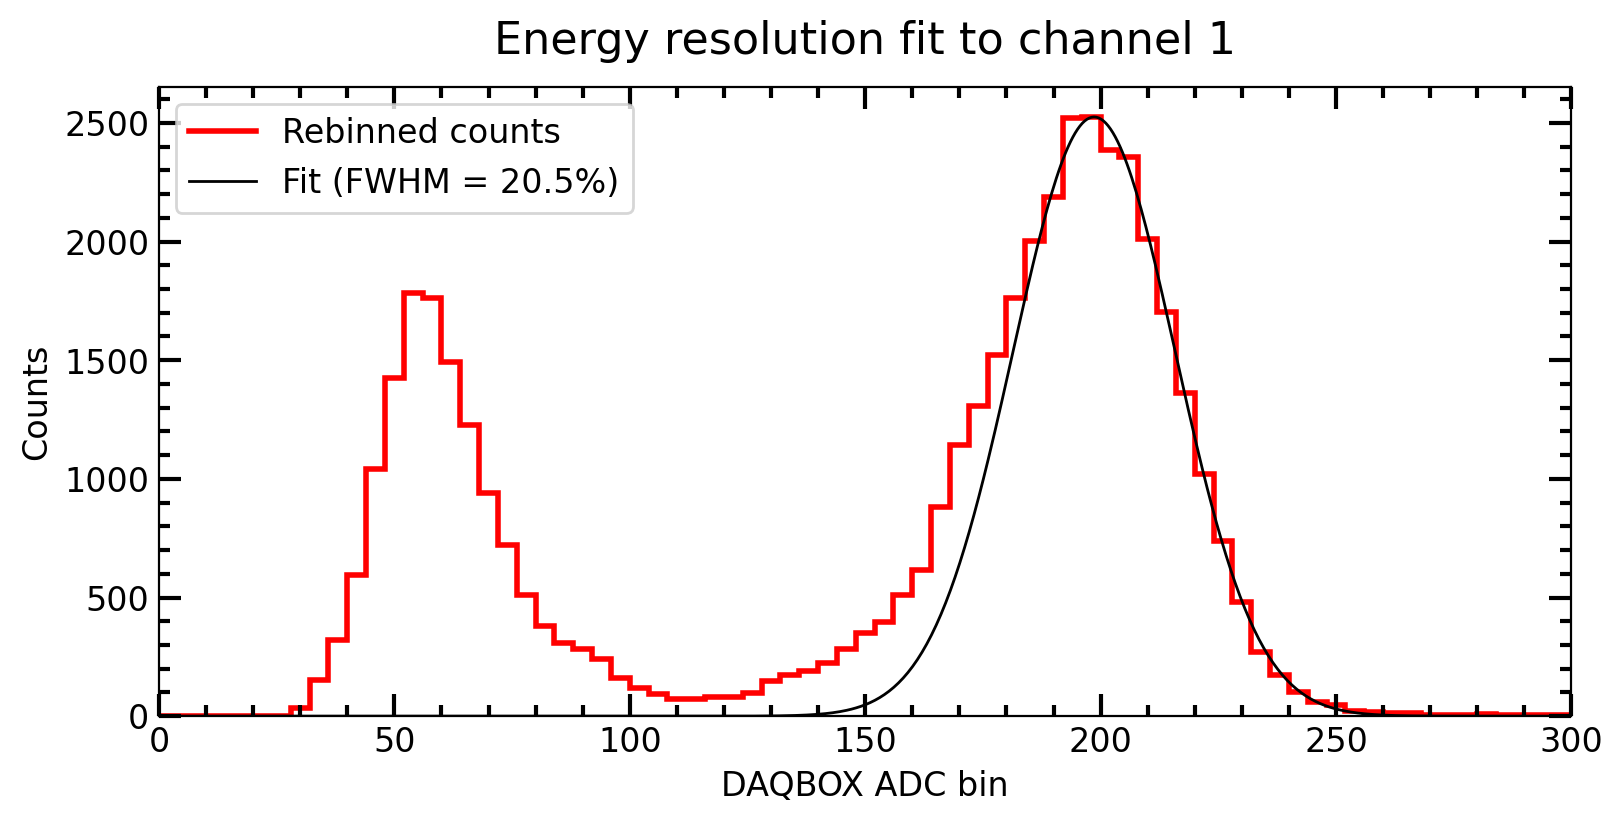

In [10]:
fig, ax = plt.subplots()
ax.stairs(rebinned_spectra[ch], rebinned_bins, color='red', lw=2, label='Rebinned counts')

_, mu, w = fit_params
fwhm = abs(2 * w * np.sqrt(np.log(2)) / mu)
smoother_bins = np.linspace(0, 1000, 2000)
ax.plot(smoother_bins, gauss(smoother_bins, *fit_params), color='black', lw=1, zorder=1, label=f'Fit (FWHM = {fwhm * 100:.1f}%)')
ax.legend()
ax.set(
    xlabel='DAQBOX ADC bin',
    ylabel='Counts',
    xlim=(0, 300),
    title=f"Energy resolution fit to channel {ch}"
)

plt.show()